### 1. Mount Google Drive

In [1]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 10.5 MB/s eta 0:00:00


In [3]:
import os
import shutil
from PyPDF2 import PdfReader, PdfWriter

base_path = '/content/drive/My Drive/Digital Forensik/dataset/'
mentah_dir = os.path.join(base_path, 'mentah')
original_dir = os.path.join(base_path, 'original')
modified_dir = os.path.join(base_path, 'modified')

# Buat direktori jika belum ada
os.makedirs(original_dir, exist_ok=True)
os.makedirs(modified_dir, exist_ok=True)

def modify_pdf_metadata(input_path, output_path, new_author="Forensic Modifier"):
    """Modifikasi metadata PDF."""
    try:
        reader = PdfReader(input_path)
        writer = PdfWriter()

        for page in reader.pages:
            writer.add_page(page)

        # Ambil metadata lama dan tambahkan/ubah
        metadata = reader.metadata
        new_metadata = {k: v for k, v in metadata.items()} if metadata else {}
        new_metadata.update({ '/Author': new_author, '/ModDate': "D:20231024000000Z" })

        writer.add_metadata(new_metadata)

        with open(output_path, 'wb') as f:
            writer.write(f)
        return True
    except Exception as e:
        print(f"Gagal memodifikasi {input_path}: {e}")
        return False

In [4]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import os

data = []

# Fungsi untuk membaca file dari folder dan membuat dataset
def load_folder_data(folder_path, label):
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.lower().endswith('.pdf'):
                # Format nama: 832_otherfile.pdf atau 832_otherfile_print.pdf
                parts = filename.split('_')
                if len(parts) >= 2: # Syaratnya minimal 2 bagian (nomor dan nama)
                    group_id = parts[0] # Mengambil bagian pertama, misal '832'
                    full_path = os.path.join(folder_path, filename)
                    data.append({
                        'filename': filename,
                        'full_path': full_path,
                        'label': label,
                        'group_id': group_id
                    })

# Memuat data dari folder original dan modified
load_folder_data(original_dir, 'original')
load_folder_data(modified_dir, 'modified')

# Membuat DataFrame
df_dataset = pd.DataFrame(data)
print(f"Total data keseluruhan: {len(df_dataset)}")

# Splitting 1: Memisahkan 80% Train dan 20% Temp (untuk Val & Test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss1.split(df_dataset, groups=df_dataset['group_id']))

train_df = df_dataset.iloc[train_idx].reset_index(drop=True)
temp_df = df_dataset.iloc[temp_idx].reset_index(drop=True)

# Splitting 2: Memisahkan Temp menjadi 50% Val dan 50% Test (setara dengan 10% & 10% dari total)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['group_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Jumlah data Train      : {len(train_df)}")
print(f"Jumlah data Validation : {len(val_df)}")
print(f"Jumlah data Test       : {len(test_df)}")

# Validasi untuk memastikan tidak ada data leakage
overlap_train_val = set(train_df['group_id']) & set(val_df['group_id'])
overlap_train_test = set(train_df['group_id']) & set(test_df['group_id'])
overlap_val_test = set(val_df['group_id']) & set(test_df['group_id'])

print(f"\nData Leakage Train vs Val  : {overlap_train_val}")
print(f"Data Leakage Train vs Test : {overlap_train_test}")
print(f"Data Leakage Val vs Test   : {overlap_val_test}")
print("(Seharusnya semua set kosong)")

print("\nContoh Data Train:")
display(train_df.head())

Total data keseluruhan: 2286
Jumlah data Train      : 1828
Jumlah data Validation : 228
Jumlah data Test       : 230

Data Leakage Train vs Val  : set()
Data Leakage Train vs Test : set()
Data Leakage Val vs Test   : set()
(Seharusnya semua set kosong)

Contoh Data Train:


,filename,full_path,label,group_id
0,406_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,406
1,258_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,258
2,165_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,165
3,391_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,391
4,176_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,176


### 2. Training Model LSTM dari Scratch

✅ GPU Terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🚀 Training akan dijalankan menggunakan GPU agar lebih cepat!

Mengekstrak dan melakukan padding pada data...


Preparing data: 100%|██████████| 230/230 [02:26<00:00,  1.57file/s]


X_train shape: (1828, 10000), y_train shape: (1828,)
X_val shape: (228, 10000), y_val shape: (228,)

MEMBANGUN & TRAINING VERSI 1: PURE BiLSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10000, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10000, 256)     │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10000, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10000, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 9996, 64)       │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2499, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 2499, 256)      │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2499, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,737 (1.70 MB)

 Trainable params: 444,481 (1.70 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7506 - loss: 0.5311
Epoch 1: val_loss improved from None to 0.62302, saving model to best_model_hybrid_cnn_lstm.keras

Epoch 1: finished saving model to best_model_hybrid_cnn_lstm.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 324ms/step - accuracy: 0.8080 - loss: 0.4601 - val_accuracy: 0.7412 - val_loss: 0.6230 - learning_rate: 5.0000e-04
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8484 - loss: 0.3688
Epoch 2: val_loss improved from 0.62302 to 0.60303, saving model to best_model_hybrid_cnn_lstm.keras

Epoch 2: finished saving model to best_model_hybrid_cnn_lstm.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.8539 - loss: 0.3651 - val_accuracy: 0.8596 - val_loss: 0.6030 - learning_rate: 5.0000e-04
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8702 - loss: 0.3531
Epoch 3: val_loss improved from 0.60303 to 0.55317, saving model to best_model_hybrid_cnn_lstm.keras

Epoch 3: fini

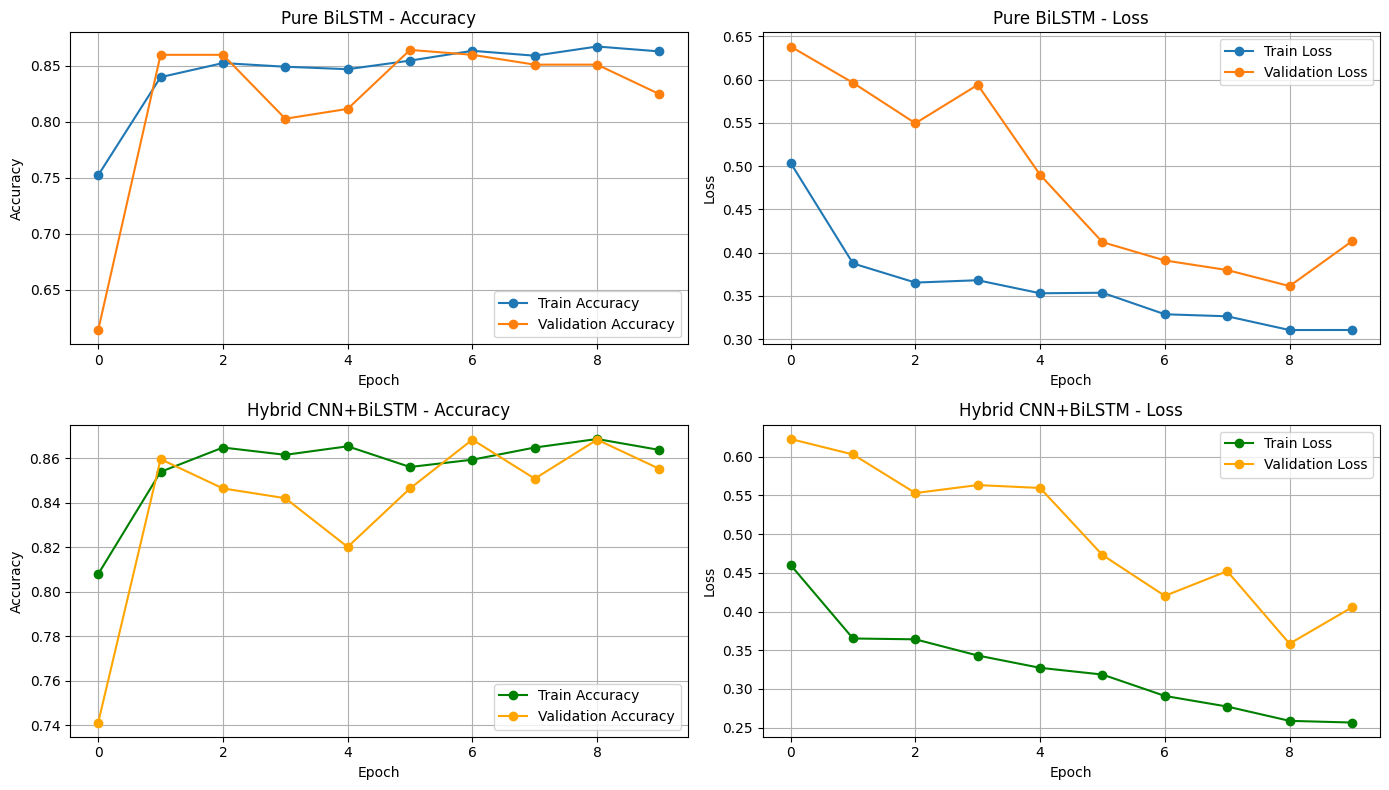

In [6]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Embedding, BatchNormalization, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CEK KETERSEDIAAN GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Terdeteksi: {gpus}")
    print("🚀 Training akan dijalankan menggunakan GPU agar lebih cepat!\n")
else:
    print("⚠️ PERINGATAN: GPU TIDAK TERDETEKSI ⚠️")
    print("Pastikan Anda telah mengubah runtime Colab: Klik 'Runtime' -> 'Change runtime type' -> Pilih 'T4 GPU' -> 'Save'.\n")

MAX_BYTE_LEN = 10000

# 1. Menyiapkan Data dari DataFrame
def prepare_data(df, max_len=MAX_BYTE_LEN):
    X, y = [], []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Preparing data",
        unit="file"
    ):
        path = row["full_path"]
        label = 1 if row["label"] == "modified" else 0

        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    bytes_content = list(f.read(max_len))

                X.append(bytes_content)
                y.append(label)

            except Exception:
                pass

    X_padded = pad_sequences(
        X,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=0
    )

    return np.array(X_padded), np.array(y)

print("Mengekstrak dan melakukan padding pada data...")
X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)
X_test, y_test = prepare_data(test_df)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

# =========================================================================
# VERSI 1: PURE BiLSTM (Tanpa CNN)
# =========================================================================
print("\n" + "="*50)
print("MEMBANGUN & TRAINING VERSI 1: PURE BiLSTM")
print("="*50)

model_bilstm = Sequential([
    Input(shape=(MAX_BYTE_LEN,)),
    Embedding(input_dim=257, output_dim=128),

    # Stacked Bidirectional LSTM (Pure)
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),

    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_pure_bilstm.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_bilstm
)

# =========================================================================
# VERSI 2: HYBRID (CNN + BiLSTM)
# =========================================================================
print("\n" + "="*50)
print("MEMBANGUN & TRAINING VERSI 2: HYBRID CNN + BiLSTM")
print("="*50)

model_hybrid = Sequential([
    Input(shape=(MAX_BYTE_LEN,)),
    Embedding(input_dim=257, output_dim=128),

    # Menambahkan CNN untuk fitur lokal
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Stacked Bidirectional LSTM
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),

    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_hybrid.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_hybrid.summary()

callbacks_hybrid = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_hybrid_cnn_lstm.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history_hybrid = model_hybrid.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_hybrid
)

# =========================================================================
# 5. Visualisasi Hasil Training Keduanya
# =========================================================================
plt.figure(figsize=(14, 8))

# Pure BiLSTM - Akurasi
plt.subplot(2, 2, 1)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Pure BiLSTM - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Pure BiLSTM - Loss
plt.subplot(2, 2, 2)
plt.plot(history_bilstm.history['loss'], label='Train Loss', marker='o')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Pure BiLSTM - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Hybrid CNN+BiLSTM - Akurasi
plt.subplot(2, 2, 3)
plt.plot(history_hybrid.history['accuracy'], label='Train Accuracy', marker='o', color='green')
plt.plot(history_hybrid.history['val_accuracy'], label='Validation Accuracy', marker='o', color='orange')
plt.title('Hybrid CNN+BiLSTM - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Hybrid CNN+BiLSTM - Loss
plt.subplot(2, 2, 4)
plt.plot(history_hybrid.history['loss'], label='Train Loss', marker='o', color='green')
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('Hybrid CNN+BiLSTM - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [7]:
import shutil
import os

# Path file dari ModelCheckpoint di local runtime
source_bilstm = 'best_model_pure_bilstm.keras'
source_hybrid = 'best_model_hybrid_cnn_lstm.keras'

# Path tujuan di Google Drive
drive_dir = '/content/drive/My Drive/Digital Forensik/'
drive_bilstm = os.path.join(drive_dir, 'best_model_pure_bilstm.keras')
drive_hybrid = os.path.join(drive_dir, 'best_model_hybrid_cnn_lstm.keras')

# Memastikan folder tujuan ada
os.makedirs(drive_dir, exist_ok=True)

# 1. Save Pure BiLSTM
if os.path.exists(source_bilstm):
    shutil.copy2(source_bilstm, drive_bilstm)
    print(f"✅ Model Pure BiLSTM berhasil disimpan ke: {drive_bilstm}")
else:
    model_bilstm.save(drive_bilstm)
    print(f"✅ Model Pure BiLSTM (dari memori) berhasil disimpan ke: {drive_bilstm}")

# 2. Save Hybrid CNN+BiLSTM
if os.path.exists(source_hybrid):
    shutil.copy2(source_hybrid, drive_hybrid)
    print(f"✅ Model Hybrid CNN+BiLSTM berhasil disimpan ke: {drive_hybrid}")
else:
    model_hybrid.save(drive_hybrid)
    print(f"✅ Model Hybrid CNN+BiLSTM (dari memori) berhasil disimpan ke: {drive_hybrid}")

✅ Model Pure BiLSTM berhasil disimpan ke: /content/drive/My Drive/Digital Forensik/best_model_pure_bilstm.keras
✅ Model Hybrid CNN+BiLSTM berhasil disimpan ke: /content/drive/My Drive/Digital Forensik/best_model_hybrid_cnn_lstm.keras


### 3. Test Data & Model LSTM


In [ ]:
from tensorflow.keras.models import load_model
import os

# Path model yang telah disimpan di Google Drive
model_path = '/content/drive/My Drive/Digital Forensik/best_model_lstm.keras'

print("Mencari model yang tersimpan...")
if os.path.exists(model_path):
    print(f"Memuat model dari: {model_path}")
    # Memuat model kembali ke dalam variabel 'model'
    model = load_model(model_path)
    print("✅ Model berhasil dimuat dan siap digunakan untuk testing!")
    model.summary()
else:
    print(f"⚠️ Model tidak ditemukan di: {model_path}")
    print("Pastikan Anda sudah menjalankan proses training dan menyimpan model ke Google Drive sebelumnya.")

import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Embedding, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# --- CEK KETERSEDIAAN GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Terdeteksi: {gpus}")
    print("🚀 Training akan dijalankan menggunakan GPU agar lebih cepat!\n")
else:
    print("⚠️ PERINGATAN: GPU TIDAK TERDETEKSI ⚠️")
    print("Pastikan Anda telah mengubah runtime Colab: Klik 'Runtime' -> 'Change runtime type' -> Pilih 'T4 GPU' -> 'Save'.\n")
# ----------------------------

MAX_BYTE_LEN = 10000

# 1. Menyiapkan Data dari DataFrame
def prepare_data(df, max_len=MAX_BYTE_LEN):
    X, y = [], []
    for _, row in df.iterrows():
        path = row["full_path"]
        label = 1 if row["label"] == "modified" else 0
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    bytes_content = list(f.read(max_len))
                X.append(bytes_content)
                y.append(label)
            except Exception as e:
                pass

    X_padded = pad_sequences(X, maxlen=max_len, padding="post", truncating="post", value=0)
    return np.array(X_padded), np.array(y)

print("Mengekstrak dan melakukan padding pada data...")
X_test, y_test = prepare_data(test_df)

Mencari model yang tersimpan...
Memuat model dari: /content/drive/My Drive/Digital Forensik/best_model_lstm.keras
✅ Model berhasil dimuat dan siap digunakan untuk testing!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10000, 64)      │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 254,757 (995.15 KB)

 Trainable params: 84,833 (331.38 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 169,668 (662.77 KB)

✅ GPU Terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🚀 Training akan dijalankan menggunakan GPU agar lebih cepat!

Mengekstrak dan melakukan padding pada data...


Memulai prediksi pada data test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step

=== HASIL EVALUASI ===
Akurasi Test: 85.22%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.78      0.99      0.87       115
Modified (1)       0.99      0.71      0.83       115

    accuracy                           0.85       230
   macro avg       0.88      0.85      0.85       230
weighted avg       0.88      0.85      0.85       230



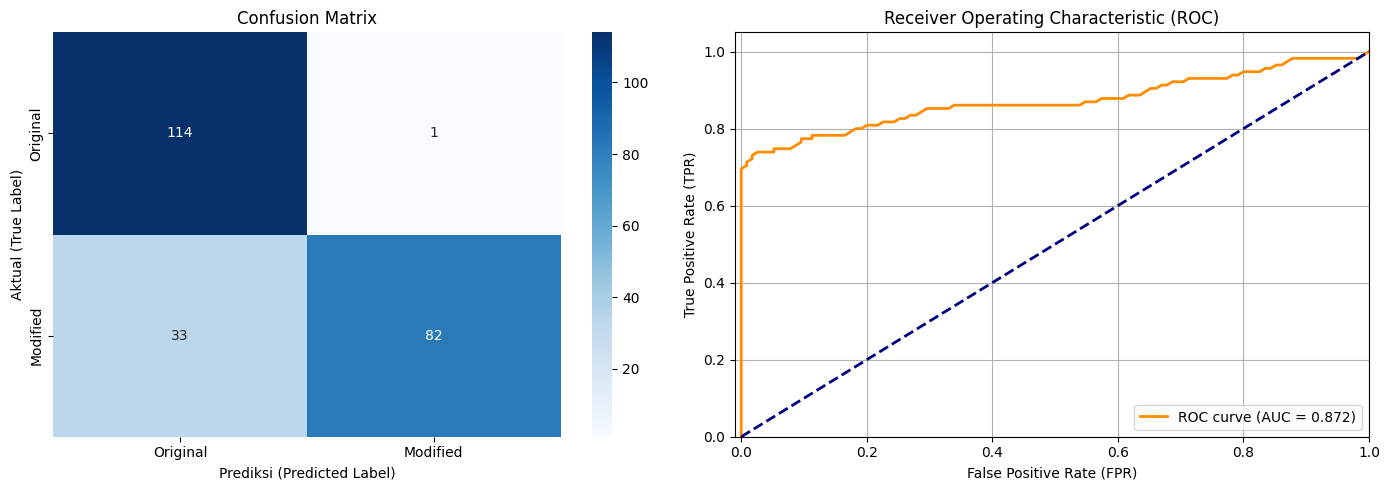

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test...")
# 1. Lakukan Prediksi
y_pred_prob = model_bilstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n=== HASIL EVALUASI ===")
print(f"Akurasi Test: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Confusion Matrix & ROC Curve
plt.figure(figsize=(14, 5))

# Plot Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

Memulai prediksi pada data test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step

=== HASIL EVALUASI ===
Akurasi Test: 86.09%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.78      1.00      0.88       115
Modified (1)       1.00      0.72      0.84       115

    accuracy                           0.86       230
   macro avg       0.89      0.86      0.86       230
weighted avg       0.89      0.86      0.86       230



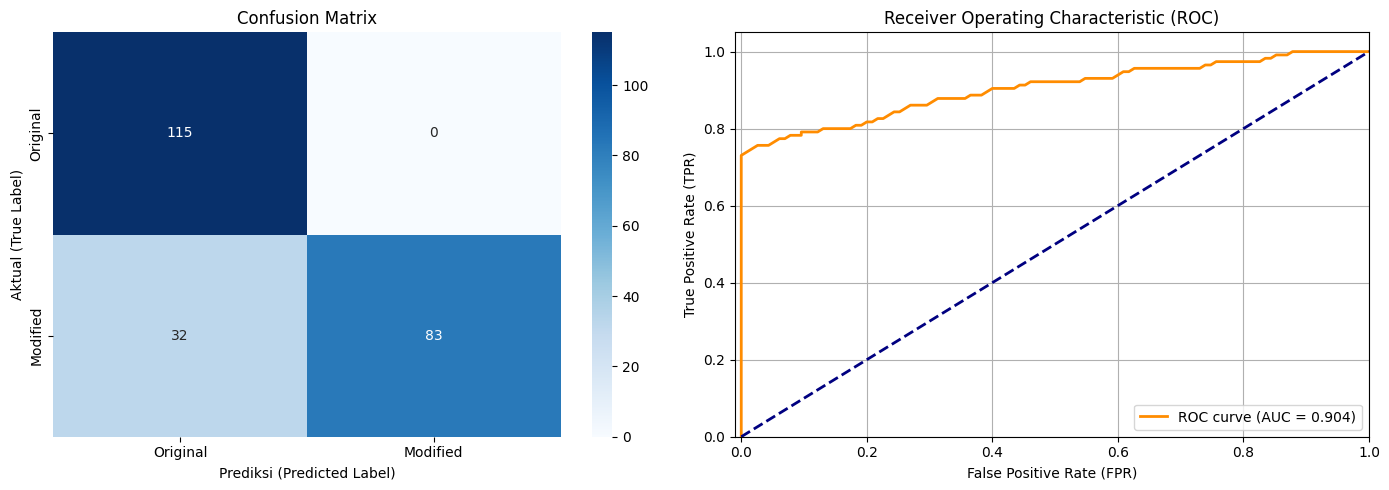

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test...")
# 1. Lakukan Prediksi
y_pred_prob = model_hybrid.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n=== HASIL EVALUASI ===")
print(f"Akurasi Test: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Confusion Matrix & ROC Curve
plt.figure(figsize=(14, 5))

# Plot Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

### Menampilkan Tingkat Keyakinan (Confidence) Prediksi

In [10]:
import pandas as pd

# Lakukan Prediksi
y_pred_prob = model_bilstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Membuat DataFrame untuk melihat hasil prediksi beserta probabilitasnya di data test
results_df = pd.DataFrame({
    'Filename': test_df['filename'],
    'Actual Label': test_df['label'],
    'Predicted Label': ['modified' if p == 1 else 'original' for p in y_pred],
    'Probabilitas Modified': y_pred_prob.flatten(),
})

# Menghitung Persentase Keyakinan (Confidence)
# Jika probabilitas >= 0.5, confidence = probabilitas
# Jika probabilitas < 0.5, confidence = 1 - probabilitas
results_df['Confidence (%)'] = results_df['Probabilitas Modified'].apply(
    lambda x: (x if x >= 0.5 else 1 - x) * 100
)

print("=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===")
display(results_df.sample(10))

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 453ms/step
=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===


,Filename,Actual Label,Predicted Label,Probabilitas Modified,Confidence (%)
194,933_transkrips_print.pdf,modified,modified,0.999341,99.934131
87,1051_otherUniv.pdf,original,original,0.210879,78.912145
118,293_edaran_print.pdf,modified,modified,0.999310,99.931026
120,303_edaran_print.pdf,modified,modified,0.999638,99.963784
18,303_edaran.pdf,original,original,0.075070,92.492966
127,362_edaran_metadataEdit.pdf,modified,original,0.148074,85.192637
105,281_edaran.pdf,original,original,0.119294,88.070563
116,281_edaran_print.pdf,modified,modified,0.999534,99.953353
76,912_transkrips.pdf,original,original,0.290635,70.936549
85,1033_transkrips.pdf,original,original,0.231595,76.840547


In [11]:
import pandas as pd

# Lakukan Prediksi
y_pred_prob = model_hybrid.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Membuat DataFrame untuk melihat hasil prediksi beserta probabilitasnya di data test
results_df = pd.DataFrame({
    'Filename': test_df['filename'],
    'Actual Label': test_df['label'],
    'Predicted Label': ['modified' if p == 1 else 'original' for p in y_pred],
    'Probabilitas Modified': y_pred_prob.flatten(),
})

# Menghitung Persentase Keyakinan (Confidence)
# Jika probabilitas >= 0.5, confidence = probabilitas
# Jika probabilitas < 0.5, confidence = 1 - probabilitas
results_df['Confidence (%)'] = results_df['Probabilitas Modified'].apply(
    lambda x: (x if x >= 0.5 else 1 - x) * 100
)

print("=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===")
display(results_df.sample(10))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===


,Filename,Actual Label,Predicted Label,Probabilitas Modified,Confidence (%)
91,1120_otherUniv.pdf,original,original,0.114785,88.521492
3,468_edaran.pdf,original,original,0.081042,91.895756
78,987_transkrips.pdf,original,original,0.171288,82.871164
5,450_edaran.pdf,original,original,0.101048,89.895229
67,13_RPS.pdf,original,original,0.068568,93.143171
178,28_RPS_compressed.pdf,modified,modified,0.888718,88.871837
134,417_edaran_metadataEdit.pdf,modified,original,0.172592,82.740824
55,565_pemberitahuan.pdf,original,original,0.081359,91.864099
8,417_edaran.pdf,original,original,0.172592,82.740824
72,109_RPS.pdf,original,original,0.062698,93.730226


### Cek Jenis PDF (Scan vs Born-Digital)
Fungsi di bawah ini menggunakan `pymupdf` untuk mendeteksi apakah suatu dokumen PDF merupakan dokumen murni (born-digital) atau hasil scan, berdasarkan keberadaan teks di dalamnya.

In [13]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 78.0 MB/s eta 0:00:00


In [14]:
import pymupdf
import os

def check_pdf_scan_or_digital(file_path):
    """Mengecek apakah PDF berupa hasil scan atau born-digital."""
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return

    print(f"Mengecek dokumen: {os.path.basename(file_path)}")
    try:
        doc = pymupdf.open(file_path)

        for i, page in enumerate(doc):
            text = page.get_text("text").strip()

            if len(text) == 0:
                print(f"  Halaman {i+1}: Kemungkinan scan (tidak ada teks terdeteksi)")
            else:
                print(f"  Halaman {i+1}: Kemungkinan born-digital (teks terdeteksi)")

        doc.close()
    except Exception as e:
        print(f"Error saat membaca file: {e}")


### Fungsi untuk Verifikasi Dokumen Baru


In [18]:
def verify_document(file_path, model, max_len=MAX_BYTE_LEN):
    """Fungsi untuk memverifikasi satu dokumen PDF dan mengembalikan persentase keyakinan."""
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return

    # 1. Baca byte stream dari file
    with open(file_path, "rb") as f:
        bytes_content = list(f.read(max_len))

    # 2. Lakukan padding sesuai ukuran input model
    X_input = pad_sequences([bytes_content], maxlen=max_len, padding="post", truncating="post", value=0)

    # 3. Lakukan prediksi (mendapatkan nilai probabilitas)
    prob = model_bilstm.predict(X_input, verbose=0)[0][0]

    # 4. Tentukan hasil berdasarkan probabilitas
    if prob >= 0.5:
        status = "MODIFIED (Telah Dimodifikasi)"
        confidence = prob * 100
    else:
        status = "ORIGINAL (Asli)"
        confidence = (1 - prob) * 100

    print("="*50)
    print(f"📄 File yang diuji  : {os.path.basename(file_path)}")
    print(f"🔍 Hasil Verifikasi : {status}")
    print(f"📈 Tingkat Keyakinan: {confidence:.2f}%")
    print("="*50)

# --- Contoh Penggunaan ---

print("Menguji Fungsi Verifikasi:\n")
sample_ori = test_df[test_df['label'] == 'original'].iloc[0]['full_path']
sample_mod = test_df[test_df['label'] == 'modified'].iloc[0]['full_path']

verify_document(sample_ori, model_bilstm)
check_pdf_scan_or_digital(sample_ori)
verify_document(sample_mod, model_bilstm)
check_pdf_scan_or_digital(sample_mod)

Menguji Fungsi Verifikasi:

📄 File yang diuji  : 259_edaran.pdf
🔍 Hasil Verifikasi : ORIGINAL (Asli)
📈 Tingkat Keyakinan: 84.18%
Mengecek dokumen: 259_edaran.pdf
  Halaman 1: Kemungkinan born-digital (teks terdeteksi)
  Halaman 2: Kemungkinan born-digital (teks terdeteksi)
  Halaman 3: Kemungkinan born-digital (teks terdeteksi)
  Halaman 4: Kemungkinan born-digital (teks terdeteksi)
  Halaman 5: Kemungkinan born-digital (teks terdeteksi)
  Halaman 6: Kemungkinan born-digital (teks terdeteksi)
  Halaman 7: Kemungkinan born-digital (teks terdeteksi)
  Halaman 8: Kemungkinan born-digital (teks terdeteksi)
  Halaman 9: Kemungkinan born-digital (teks terdeteksi)
  Halaman 10: Kemungkinan born-digital (teks terdeteksi)
📄 File yang diuji  : 272_edaran_print.pdf
🔍 Hasil Verifikasi : MODIFIED (Telah Dimodifikasi)
📈 Tingkat Keyakinan: 99.95%
Mengecek dokumen: 272_edaran_print.pdf
  Halaman 1: Kemungkinan born-digital (teks terdeteksi)


### 4. Training Model - Versi Chunk Based
Pada pendekatan ini, daripada membaca file sebagai satu sekuens panjang (misal 10.000 byte), kita akan memecahnya menjadi beberapa *chunk* (misal per 1000 byte). Masing-masing chunk dari sebuah file akan diberi label yang sama dengan file aslinya.

In [21]:
import numpy as np
import os
import tensorflow as tf

CHUNK_SIZE = 1000
MAX_CHUNKS_PER_FILE = 20  # Maksimal 20 chunk per file (total representasi 10.000 byte)

def prepare_data_chunked(df, chunk_size=CHUNK_SIZE, max_chunks=MAX_CHUNKS_PER_FILE):
    X_chunked, y_chunked = [], []
    for _, row in df.iterrows():
        path = row["full_path"]
        label = 1 if row["label"] == "modified" else 0
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    # Baca byte sesuai batas maksimal yang ingin kita olah
                    bytes_content = f.read(chunk_size * max_chunks)

                    # Pecah menjadi beberapa chunk
                    for i in range(0, len(bytes_content), chunk_size):
                        chunk = list(bytes_content[i:i+chunk_size])
                        # Lakukan padding pada chunk terakhir jika kurang dari chunk_size
                        if len(chunk) < chunk_size:
                            chunk = chunk + [0] * (chunk_size - len(chunk))

                        X_chunked.append(chunk)
                        y_chunked.append(label)
            except Exception as e:
                pass

    return np.array(X_chunked), np.array(y_chunked)

print("Mengekstrak dan memecah data menjadi chunk...")
X_train_chunk, y_train_chunk = prepare_data_chunked(train_df)
X_val_chunk, y_val_chunk = prepare_data_chunked(val_df)
X_test_chunk, y_test_chunk = prepare_data_chunked(test_df)

print(f"X_train_chunk shape: {X_train_chunk.shape}, y_train_chunk shape: {y_train_chunk.shape}")
print(f"X_val_chunk shape: {X_val_chunk.shape}, y_val_chunk shape: {y_val_chunk.shape}")

Mengekstrak dan memecah data menjadi chunk...


Test Chunk Data: 100%|██████████| 230/230 [00:00<00:00, 852.94it/s]


X_train_chunk shape: (18266, 1000), y_train_chunk shape: (18266,)
X_val_chunk shape: (2280, 1000), y_val_chunk shape: (2280,)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dropout, BatchNormalization, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Membangun Model untuk Chunk-Based
# Karena sequence length lebih pendek (1000 vs 10000), komputasi per langkah akan lebih ringan

model_chunk = Sequential([
    Input(shape=(CHUNK_SIZE,)),
    Embedding(input_dim=257, output_dim=64),

    # CNN untuk ekstraksi pola byte lokal di dalam chunk
    Conv1D(filters=32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=4),

    # BiGRU untuk sequence learning di dalam chunk
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(32)),

    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_chunk.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model_chunk.summary()

callbacks_chunk = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_chunk.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("\nMemulai training model versi Chunk-Based...")
history_chunk = model_chunk.fit(
    X_train_chunk, y_train_chunk,
    epochs=20,
    batch_size=64, # Batch size bisa lebih besar karena dimensi sequence lebih kecil
    validation_data=(X_val_chunk, y_val_chunk),
    callbacks=callbacks_chunk
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 1000, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 996, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 249, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 249, 128)       │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 249, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,825 (382.13 KB)

 Trainable params: 97,697 (381.63 KB)

 Non-trainable params: 128 (512.00 B)


Memulai training model versi Chunk-Based...
Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5693 - loss: 0.6683
Epoch 1: val_loss improved from None to 0.67392, saving model to best_model_chunk.keras

Epoch 1: finished saving model to best_model_chunk.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.6080 - loss: 0.6435 - val_accuracy: 0.5825 - val_loss: 0.6739 - learning_rate: 0.0010
Epoch 2/20
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6971 - loss: 0.5742
Epoch 2: val_loss did not improve from 0.67392
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6932 - loss: 0.5782 - val_accuracy: 0.5009 - val_loss: 0.8323 - learning_rate: 0.0010
Epoch 3/20
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7462 - loss: 0.5251
Epoch 3: val_loss did not improve from 0.67392
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7415 - loss: 0.5310 - val_accuracy: 0.5241 - val_loss: 0.9926 - learning_rate: 0.0010
Epoch 4/20
285/286 ━━━━━━

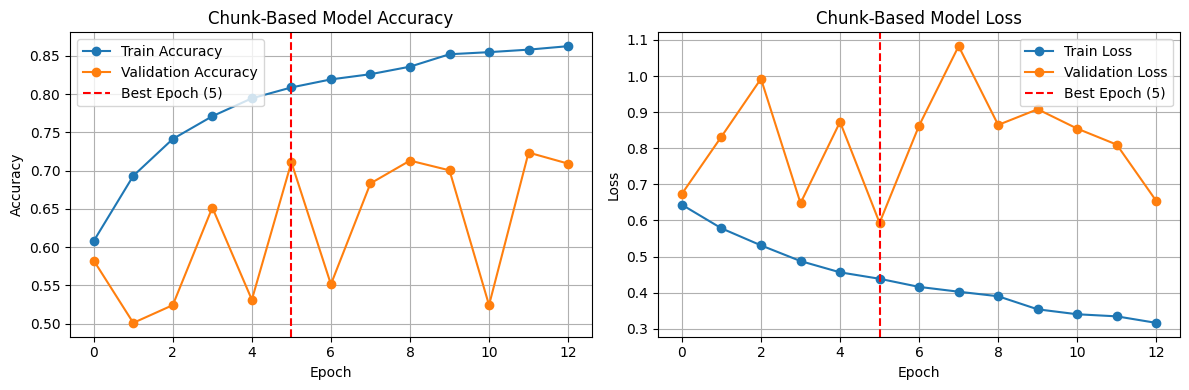

In [23]:
# Visualisasi Hasil Training Model Chunk-Based
best_epoch_chunk = np.argmin(history_chunk.history['val_loss'])
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_chunk.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_chunk.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axvline(x=best_epoch_chunk, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_chunk})')
plt.title('Chunk-Based Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_chunk.history['loss'], label='Train Loss', marker='o')
plt.plot(history_chunk.history['val_loss'], label='Validation Loss', marker='o')
plt.axvline(x=best_epoch_chunk, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_chunk})')
plt.title('Chunk-Based Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Evaluasi Model Chunk-Based
Mari kita uji performa model chunk-based menggunakan data test yang telah dipecah menjadi chunk.

Memulai prediksi pada data test (Chunk-Based)...
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

=== HASIL EVALUASI (CHUNK-BASED) ===
Akurasi Test: 72.48%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.70      0.78      0.74      1150
Modified (1)       0.75      0.67      0.71      1150

    accuracy                           0.72      2300
   macro avg       0.73      0.72      0.72      2300
weighted avg       0.73      0.72      0.72      2300



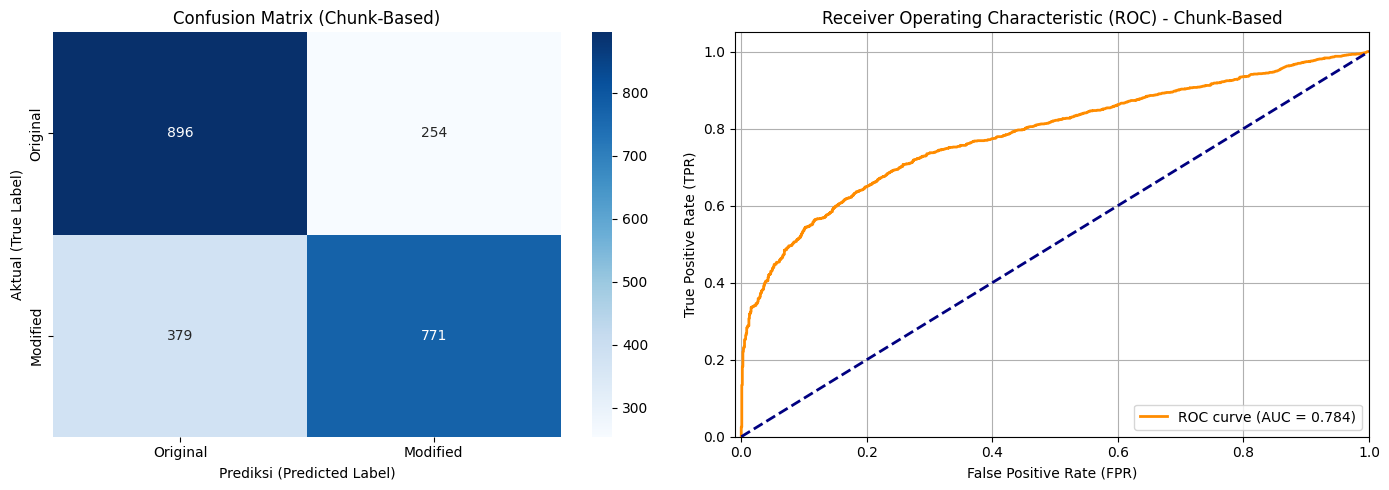

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test (Chunk-Based)...")
# 1. Lakukan Prediksi
y_pred_prob_chunk = model_chunk.predict(X_test_chunk)
y_pred_chunk = (y_pred_prob_chunk > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc_chunk = accuracy_score(y_test_chunk, y_pred_chunk)
print(f"\n=== HASIL EVALUASI (CHUNK-BASED) ===")
print(f"Akurasi Test: {acc_chunk * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_chunk, y_pred_chunk, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Confusion Matrix & ROC Curve
plt.figure(figsize=(14, 5))

# Plot Confusion Matrix
plt.subplot(1, 2, 1)
cm_chunk = confusion_matrix(y_test_chunk, y_pred_chunk)
sns.heatmap(cm_chunk, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix (Chunk-Based)')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr_chunk, tpr_chunk, thresholds_chunk = roc_curve(y_test_chunk, y_pred_prob_chunk)
roc_auc_chunk = auc(fpr_chunk, tpr_chunk)

plt.plot(fpr_chunk, tpr_chunk, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_chunk:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Chunk-Based')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

### Contoh Ekstraksi Byte dari Satu Dokumen PDF dan Perhitungan Nilai Entropy

In [16]:
import os

sample_file_path = test_df[test_df['label'] == 'original'].iloc[0]['full_path']

print(f"Mengekstrak byte dari file: {os.path.basename(sample_file_path)}")

try:
    with open(sample_file_path, "rb") as f:
        bytes_content = list(f.read(200))

    print(f"Total byte yang dibaca: {len(bytes_content)}")
    print("\n--- 200 Byte Pertama ---")
    print(bytes_content[:200])

except Exception as e:
    print(f"Gagal membaca file {sample_file_path}: {e}")

Mengekstrak byte dari file: 259_edaran.pdf
Total byte yang dibaca: 200

--- 200 Byte Pertama ---
[37, 80, 68, 70, 45, 49, 46, 51, 10, 37, 196, 229, 242, 229, 235, 167, 243, 160, 208, 196, 198, 10, 51, 32, 48, 32, 111, 98, 106, 10, 60, 60, 32, 47, 70, 105, 108, 116, 101, 114, 32, 47, 70, 108, 97, 116, 101, 68, 101, 99, 111, 100, 101, 32, 47, 76, 101, 110, 103, 116, 104, 32, 53, 56, 53, 54, 32, 62, 62, 10, 115, 116, 114, 101, 97, 109, 10, 120, 1, 189, 157, 91, 115, 220, 200, 117, 199, 223, 241, 41, 144, 183, 97, 202, 130, 6, 215, 25, 56, 91, 91, 225, 138, 27, 89, 90, 75, 150, 37, 42, 46, 87, 156, 74, 173, 164, 93, 73, 166, 69, 209, 75, 179, 236, 228, 211, 251, 119, 186, 207, 193, 165, 209, 192, 128, 228, 48, 47, 26, 98, 6, 56, 221, 231, 246, 63, 151, 238, 134, 254, 154, 62, 126, 149, 126, 243, 77, 250, 248, 197, 147, 103, 103, 233, 54, 253, 246, 219, 244, 187, 179, 39, 233, 239, 211, 191, 114, 177, 205, 182, 219, 109, 217, 52, 69, 158, 214, 109, 157, 85, 85, 186, 175, 242, 172, 205, 219,

In [17]:
import os
import math
from collections import Counter
import numpy as np
import pandas as pd
from IPython.display import display

def calculate_entropy(data_sequence):
    """Menghitung Shannon Entropy dari sebuah sequence data."""
    if not data_sequence:
        return 0.0

    counts = Counter(data_sequence)
    total_len = len(data_sequence)

    entropy = 0.0
    for count in counts.values():
        p_x = count / total_len
        if p_x > 0:
            entropy -= p_x * math.log2(p_x)
    return entropy

# Ambil 10 sampel dokumen secara acak dari data test
sample_files = test_df.sample(10, random_state=42)
max_len = 10000

print("Menganalisis Entropi dari 10 dokumen...\n")

results = []

for idx, row in sample_files.iterrows():
    file_path = row['full_path']
    label = row['label']
    filename = row['filename']

    if os.path.exists(file_path):
        with open(file_path, "rb") as f:
            raw_bytes = f.read(max_len)

        # Metode 1: Ekstraksi Byte List (f.read langsung)
        byte_list = list(raw_bytes)
        entropy_byte = calculate_entropy(byte_list)

        # Metode 2: Ekstraksi Char-level Tokenization
        string_content = str(raw_bytes)
        char_tokens = [ord(char) for char in string_content]
        entropy_char = calculate_entropy(char_tokens)

        results.append({
            "Filename": filename,
            "Label": label,
            "Entropi (Byte List)": round(entropy_byte, 4),
            "Entropi (Char Token)": round(entropy_char, 4),
            "Selisih": round(entropy_byte - entropy_char, 4)
        })

# Tampilkan hasil dalam bentuk DataFrame agar rapi
df_entropy_results = pd.DataFrame(results)
display(df_entropy_results)

print("\nCATATAN:")
print("- Entropi (Byte List): Dihitung dari list murni nilai byte integer 0-255.")
print("- Entropi (Char Token): Dihitung dari konversi representasi string (termasuk karakter 'b', '\\x', dll).")
print("- Metode Char Token umumnya menghasilkan entropi yang lebih rendah secara konsisten pada file PDF karena representasi string mengubah byte non-printable menjadi urutan karakter seperti '\\x00', '\\n', dll. Hal ini meningkatkan frekuensi karakter tertentu (seperti '\\' dan 'x'), sehingga mengurangi tingkat keacakan/kompleksitas relatif terhadap panjang total sequence.")


Menganalisis Entropi dari 10 dokumen...



,Filename,Label,Entropi (Byte List),Entropi (Char Token),Selisih
0,157_edaran_compressed.pdf,modified,7.9336,4.3633,3.5703
1,28_RPS.pdf,original,7.1223,4.0342,3.0880
2,341_edaran.pdf,original,7.2143,4.6348,2.5795
3,920_transkrips_compressed.pdf,modified,7.9712,4.3217,3.6495
4,425_edaran.pdf,original,7.8476,4.4282,3.4194
5,987_transkrips_metadataEdit.pdf,modified,7.6763,4.5604,3.1159
6,413_edaran.pdf,original,7.8446,4.4398,3.4048
7,943_transkrips_print.pdf,modified,7.9130,4.3580,3.5550
8,571_pemberitahuan_editContent.pdf,modified,6.9945,4.3726,2.6219
9,356_edaran_metadataEdit.pdf,modified,7.7616,4.5354,3.2261



CATATAN:
- Entropi (Byte List): Dihitung dari list murni nilai byte integer 0-255.
- Entropi (Char Token): Dihitung dari konversi representasi string (termasuk karakter 'b', '\x', dll).
- Metode Char Token umumnya menghasilkan entropi yang lebih rendah secara konsisten pada file PDF karena representasi string mengubah byte non-printable menjadi urutan karakter seperti '\x00', '\n', dll. Hal ini meningkatkan frekuensi karakter tertentu (seperti '\' dan 'x'), sehingga mengurangi tingkat keacakan/kompleksitas relatif terhadap panjang total sequence.
